# Livro para consulta:
- https://jakevdp.github.io/PythonDataScienceHandbook/03.08-aggregation-and-grouping.html
- https://jakevdp.github.io/PythonDataScienceHandbook/03.09-pivot-tables.html
    

# 1. Importando bibliotecas <a name="import"></a>

<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# 2. Carregando o dataframe SINASC <a name="read"></a>
<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [6]:
sinasc_raw = pd.read_csv('C:/Users/gusta/Documents/DCEB/DatasetsSINASC_RO_2019.csv')
sinasc_raw.head()

,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,KOTELCHUCK,CONTADOR,munResStatus,munResTipo,munResNome,munResUf,munResLat,munResLon,munResAlt,munResArea
0,1,2679477.0,110001,1,19,5.0,8 a 11 anos,NaN,0.0,0.0,...,5,1,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
1,1,2679477.0,110001,1,29,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,2,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
2,1,2679477.0,110001,1,37,9.0,8 a 11 anos,513205.0,2.0,0.0,...,5,3,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
3,1,2516500.0,110001,1,30,5.0,12 anos ou mais,231205.0,0.0,0.0,...,4,4,ATIVO,MUNIC,Alto Alegre dos Parecis,Rondônia,-12.13178,-61.85308,397.0,3958.273
4,1,2516500.0,110001,1,30,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,5,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025


In [70]:
sinasc_raw.columns

Index(['ORIGEM', 'CODESTAB', 'CODMUNNASC', 'LOCNASC', 'IDADEMAE', 'ESTCIVMAE',
       'ESCMAE', 'CODOCUPMAE', 'QTDFILVIVO', 'QTDFILMORT', 'CODMUNRES',
       'GESTACAO', 'GRAVIDEZ', 'PARTO', 'CONSULTAS', 'DTNASC', 'HORANASC',
       'SEXO', 'APGAR1', 'APGAR5', 'RACACOR', 'PESO', 'IDANOMAL', 'DTCADASTRO',
       'CODANOMAL', 'NUMEROLOTE', 'VERSAOSIST', 'DTRECEBIM', 'DIFDATA',
       'DTRECORIGA', 'NATURALMAE', 'CODMUNNATU', 'CODUFNATU', 'ESCMAE2010',
       'SERIESCMAE', 'DTNASCMAE', 'RACACORMAE', 'QTDGESTANT', 'QTDPARTNOR',
       'QTDPARTCES', 'IDADEPAI', 'DTULTMENST', 'SEMAGESTAC', 'TPMETESTIM',
       'CONSPRENAT', 'MESPRENAT', 'TPAPRESENT', 'STTRABPART', 'STCESPARTO',
       'TPNASCASSI', 'TPFUNCRESP', 'TPDOCRESP', 'DTDECLARAC', 'ESCMAEAGR1',
       'STDNEPIDEM', 'STDNNOVA', 'CODPAISRES', 'TPROBSON', 'PARIDADE',
       'KOTELCHUCK', 'CONTADOR', 'munResStatus', 'munResTipo', 'munResNome',
       'munResUf', 'munResLat', 'munResLon', 'munResAlt', 'munResArea'],
      dtype='object')

# Tarefa 1

### 1. Idade media das mães e dos pais por município (coluna munResNome)


In [54]:
sinasc_ex1 = sinasc_raw[['IDADEMAE', 'IDADEPAI', 'munResNome']]
sinasc_ex1

,IDADEMAE,IDADEPAI,munResNome
6956,11,NaN,Alto Paraíso
8098,12,NaN,Costa Marques
17391,12,NaN,Ji-Paraná
23389,12,NaN,Porto Velho
21712,12,18.0,Porto Velho
...,...,...,...
15344,47,35.0,Cacoal
18592,51,NaN,Nova Brasilândia D'Oeste
18901,52,NaN,Vale do Paraíso
13801,53,32.0,Alta Floresta D'Oeste


In [238]:
result = sinasc_ex1.groupby('munResNome').median()
result

,IDADEMAE,IDADEPAI
munResNome,,
Alta Floresta D'Oeste,25.0,28.5
Alto Alegre dos Parecis,25.0,28.0
Alto Paraíso,24.0,25.5
Alvorada D'Oeste,25.0,31.0
Ariquemes,25.0,29.0
Buritis,25.0,28.5
Cabixi,26.0,35.5
Cacaulândia,25.0,33.5
Cacoal,26.0,30.0


### insights:
- O pai mais velho tem 40 anos e a mãe mais velha tem 28, mostrando uma provavel grande diferença de idades
- Na maior parte das cidades o pai é mais velho

### 2. Peso médio dos bebes por sexo que nasceram no dia do seu aniversário por faixas de escolaridade mae
Ex: Você, aluna(o), nasceu no dia 10/01, então você precisa filtrar o conjunto de dados nessa data e calcular o peso médio dos bebês de cada sexo por faixa de escolaridade da mãe.

In [130]:
sinasc_ex2 = sinasc_raw[['SEXO', 'ESCMAE', 'PESO', 'DTNASC']].copy()
sinasc_ex2['DTNASC'] = pd.to_datetime(sinasc_ex2['DTNASC'], errors='coerce')

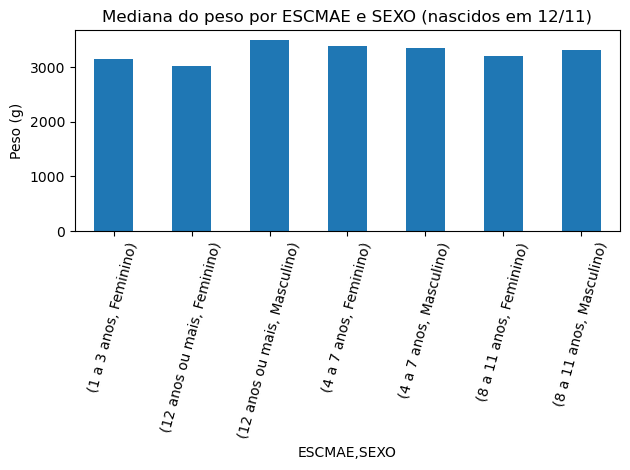

In [248]:
result = sinasc_ex2[(sinasc_ex2['DTNASC'].dt.day == 12) & (sinasc_ex2['DTNASC'].dt.month == 11)].groupby(['ESCMAE', 'SEXO'])['PESO'].median()

result.plot(kind='bar')
plt.title("Mediana do peso por ESCMAE e SEXO (nascidos em 12/11)")
plt.ylabel("Peso (g)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### insights:
- A média dos bebes masculinos é maior
- Quanto maior a escolaridade maior é o peso do bebe, provavelmente relacionado as condições de vida

### 3. Qual o municipio que nasceu menos bebe em 2019?
    - qual a idade media, maxima, minima das maes nesse municipio?
    - qual a idade media, maxima, minima dos pais nesse municipio?

In [260]:
sinasc_raw['munResNome'].unique()

array(["Alta Floresta D'Oeste", 'Alto Alegre dos Parecis',
       'Novo Horizonte do Oeste', 'Rolim de Moura', "São Felipe D'Oeste",
       'Ariquemes', 'Cujubim', 'Alto Paraíso', 'Monte Negro', 'Jaru',
       'Rio Crespo', 'Porto Velho', 'Cacaulândia', 'Itapuã do Oeste',
       'Ji-Paraná', 'Buritis', 'Vilhena', 'Vale do Anari',
       'Candeias do Jamari', 'Costa Marques', 'Campo Novo de Rondônia',
       "Machadinho D'Oeste", 'Colorado do Oeste', 'Nova Mamoré', 'Urupá',
       'Ouro Preto do Oeste', 'Corumbiara', 'São Miguel do Guaporé',
       'Governador Jorge Teixeira', "Santa Luzia D'Oeste",
       'Pimenta Bueno', 'Mirante da Serra', 'Cerejeiras',
       'Presidente Médici', 'Cacoal', 'Parecis', "Espigão D'Oeste",
       'São Francisco do Guaporé', 'Ministro Andreazza',
       "Nova Brasilândia D'Oeste", "Alvorada D'Oeste",
       'Primavera de Rondônia', 'Seringueiras', 'Município ignorado - RO',
       'Castanheiras', 'Chupinguaia', 'Guajará-Mirim', 'Theobroma',
       'Nova 

In [252]:
nascimentos_por_municipio = sinasc_raw.groupby('munResNome').size()
municipio_menos_nascimentos = nascimentos_por_municipio.idxmin()
quantidade = nascimentos_por_municipio.min()

print(f"O município com menos nascimentos em 2019 foi '{municipio_menos_nascimentos}' com {quantidade} nascimento(s).")

O município com menos nascimentos em 2019 foi 'Município ignorado - RO' com 1 nascimento(s).


In [264]:
sinasc_ex3 = sinasc_raw[['munResNome', 'IDADEPAI', 'IDADEMAE']]
result = sinasc_ex3[sinasc_ex3.munResNome == 'Município ignorado - RO'].groupby('munResNome')[['IDADEMAE', 'IDADEPAI']].aggregate(['min', 'median', 'max'])
result

IDADEMAE            IDADEPAI             
                             min median max      min median   max
munResNome                                                       
Município ignorado - RO       24   24.0  24     22.0   22.0  22.0

### insights:
- O município com o menor número de nascimentos foi o ignorado, com 1
- a idade média dos seus pais gira em torno de 23 anos

### 4. Qual o municipio que nasceu mais bebe no mês de março?
    - qual a quantidade de filhos vivos media, maxima, minima nesse municipio?
    - qual a idade media, maxima, minima dos pais nesse municipio?


In [304]:
sinasc_raw['DTNASC'] = pd.to_datetime(sinasc_raw['DTNASC'], errors='coerce')
nasc_marco = sinasc_raw[sinasc_raw['DTNASC'].dt.month == 3]

nascimentos_marco_por_municipio = nasc_marco['munResNome'].value_counts()

municipio_mais_nasc_marco = nascimentos_marco_por_municipio.idxmax()
qtd_nasc_marco = nascimentos_marco_por_municipio.max()

print(f" O município com mais nascimentos em março foi '{municipio_mais_nasc_marco}' com {qtd_nasc_marco} nascimento(s).")

resultado = nasc_marco[nasc_marco.munResNome == municipio_mais_nasc_marco].groupby('munResNome')[['QTDFILVIVO', 'IDADEPAI', 'IDADEMAE']].agg(['min', 'median', 'max'])
resultado

 O município com mais nascimentos em março foi 'Porto Velho' com 744 nascimento(s).


QTDFILVIVO             IDADEPAI              IDADEMAE           
                   min median  max      min median   max      min median max
munResNome                                                                  
Porto Velho        0.0    1.0  9.0     19.0   34.0  62.0       14   26.0  44

- o máximo de filhos foi 9
- a idade da mãe mais nova é 14, menor de idade
- a média da idade dos pais é superior a das mães

### Analise as respostas encontradas, tire algum insight delas, conte pra gente algo encontrado nos dados. Algo que você julgue relevante e novo pra você.

In [ ]:
Conclu

In [6]:
sinasc_raw.dtypes

ORIGEM          int64
CODESTAB      float64
CODMUNNASC      int64
LOCNASC         int64
IDADEMAE        int64
               ...   
munResUf       object
munResLat     float64
munResLon     float64
munResAlt     float64
munResArea    float64
Length: 69, dtype: object

In [7]:
sinasc_raw.select_dtypes(exclude=['int64','float64'])

,ESCMAE,GESTACAO,GRAVIDEZ,PARTO,DTNASC,SEXO,RACACOR,DTCADASTRO,CODANOMAL,VERSAOSIST,DTRECEBIM,munResStatus,munResTipo,munResNome,munResUf
0,8 a 11 anos,37 a 41 semanas,Única,Cesáreo,2019-02-19,Masculino,Branca,2019-03-08,NaN,3.2.01,2019-03-08,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia
1,8 a 11 anos,37 a 41 semanas,Única,Cesáreo,2019-02-21,Feminino,Branca,2019-03-08,NaN,3.2.01,2019-03-08,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia
2,8 a 11 anos,37 a 41 semanas,Única,Cesáreo,2019-02-25,Feminino,Branca,2019-03-08,NaN,3.2.01,2019-03-08,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia
3,12 anos ou mais,37 a 41 semanas,Única,Cesáreo,2019-03-20,Feminino,Parda,2019-04-03,NaN,3.2.01,2019-04-09,ATIVO,MUNIC,Alto Alegre dos Parecis,Rondônia
4,8 a 11 anos,37 a 41 semanas,Única,Cesáreo,2019-03-23,Feminino,Parda,2019-04-03,NaN,3.2.01,2019-04-09,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27023,12 anos ou mais,32 a 36 semanas,Única,Cesáreo,2019-12-13,Masculino,Branca,2020-09-28,NaN,3.2.01,2020-10-13,ATIVO,MUNIC,Vilhena,Rondônia
27024,8 a 11 anos,37 a 41 semanas,Única,Vaginal,2019-10-04,Masculino,Branca,2019-10-16,NaN,3.2.01,2019-10-21,ATIVO,MUNIC,Chupinguaia,Rondônia
27025,8 a 11 anos,37 a 41 semanas,Única,Cesáreo,2019-08-02,Masculino,Parda,2019-08-07,NaN,3.2.00,2019-08-07,ATIVO,MUNIC,Vilhena,Rondônia
27026,8 a 11 anos,32 a 36 semanas,Única,Vaginal,2019-12-23,Masculino,Parda,2020-01-07,NaN,3.2.00,2020-01-07,ATIVO,MUNIC,Vilhena,Rondônia


In [4]:
sinasc_raw.columns

Index(['ORIGEM', 'CODESTAB', 'CODMUNNASC', 'LOCNASC', 'IDADEMAE', 'ESTCIVMAE',
       'ESCMAE', 'CODOCUPMAE', 'QTDFILVIVO', 'QTDFILMORT', 'CODMUNRES',
       'GESTACAO', 'GRAVIDEZ', 'PARTO', 'CONSULTAS', 'DTNASC', 'HORANASC',
       'SEXO', 'APGAR1', 'APGAR5', 'RACACOR', 'PESO', 'IDANOMAL', 'DTCADASTRO',
       'CODANOMAL', 'NUMEROLOTE', 'VERSAOSIST', 'DTRECEBIM', 'DIFDATA',
       'DTRECORIGA', 'NATURALMAE', 'CODMUNNATU', 'CODUFNATU', 'ESCMAE2010',
       'SERIESCMAE', 'DTNASCMAE', 'RACACORMAE', 'QTDGESTANT', 'QTDPARTNOR',
       'QTDPARTCES', 'IDADEPAI', 'DTULTMENST', 'SEMAGESTAC', 'TPMETESTIM',
       'CONSPRENAT', 'MESPRENAT', 'TPAPRESENT', 'STTRABPART', 'STCESPARTO',
       'TPNASCASSI', 'TPFUNCRESP', 'TPDOCRESP', 'DTDECLARAC', 'ESCMAEAGR1',
       'STDNEPIDEM', 'STDNNOVA', 'CODPAISRES', 'TPROBSON', 'PARIDADE',
       'KOTELCHUCK', 'CONTADOR', 'munResStatus', 'munResTipo', 'munResNome',
       'munResUf', 'munResLat', 'munResLon', 'munResAlt', 'munResArea'],
      dtype='object')